In [13]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("student.csv")
print(data.head())

   Student_ID  Gender  Age  Study_Hours_per_Week  Attendance_Percentage  \
0           1    Male   23                    14                     67   
1           2  Female   24                    34                     98   
2           3    Male   18                    29                     77   
3           4    Male   18                    24                     96   
4           5    Male   18                     9                     60   

   Previous_Grade  Internet_Usage_Hours  Final_Score Result  
0              80                     4        32.73   Fail  
1              51                     8        46.08   Fail  
2              88                     7        49.32   Fail  
3              54                     9        44.09   Fail  
4              70                     5        31.05   Fail  


In [14]:
# Info

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             1000 non-null   int64  
 1   Gender                 1000 non-null   object 
 2   Age                    1000 non-null   int64  
 3   Study_Hours_per_Week   1000 non-null   int64  
 4   Attendance_Percentage  1000 non-null   int64  
 5   Previous_Grade         1000 non-null   int64  
 6   Internet_Usage_Hours   1000 non-null   int64  
 7   Final_Score            1000 non-null   float64
 8   Result                 1000 non-null   object 
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


In [30]:
# PART-A :- DESCRIPTIVE ANALYTICS

data.describe()

,Student_ID,Age,Study_Hours_per_Week,Attendance_Percentage,Previous_Grade,Internet_Usage_Hours,Final_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,21.005000,22.062000,74.784000,67.057000,5.046000,42.527430
std,288.819436,2.040377,10.101495,14.454144,15.898507,2.554292,9.365631
min,1.000000,18.000000,5.000000,50.000000,40.000000,1.000000,19.900000
25%,250.750000,19.000000,13.000000,62.000000,54.000000,3.000000,35.745000
50%,500.500000,21.000000,22.000000,75.000000,67.000000,5.000000,42.525000
75%,750.250000,23.000000,31.000000,87.000000,81.000000,7.000000,49.547500
max,1000.000000,24.000000,39.000000,99.000000,94.000000,9.000000,70.480000


In [23]:
# Average Score
avg_score = data['Final_Score'].mean()
print("Average Score",avg_score)

# Pass & Fail Count
data['Result'].value_counts()

Average Score 42.527429999999995


Result
Fail    762
Pass    238
Name: count, dtype: int64

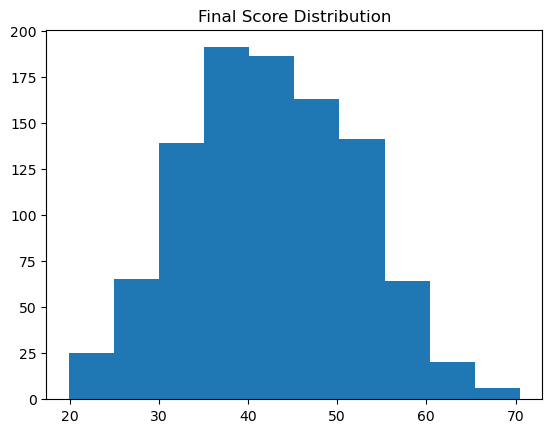

In [31]:
# Visualization

# Final Score Distribution 
plt.hist(data['Final_Score'])
plt.title("Final Score Distribution")
plt.show()

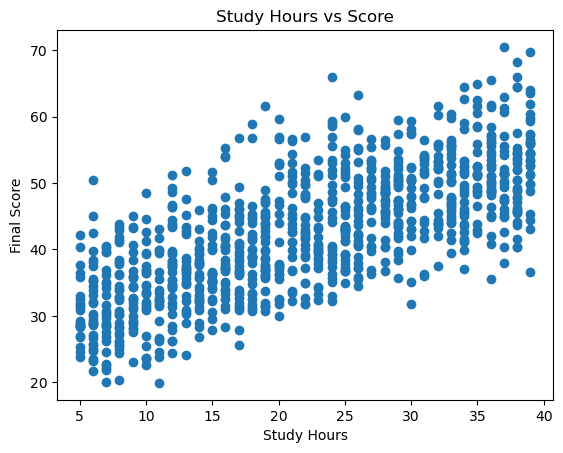

In [32]:
# Study Hours VS Score
plt.scatter(data['Study_Hours_per_Week'], data['Final_Score'])
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Score")
plt.show()

                       Student_ID       Age  Study_Hours_per_Week  \
Student_ID               1.000000 -0.008696              0.014166   
Age                     -0.008696  1.000000              0.008387   
Study_Hours_per_Week     0.014166  0.008387              1.000000   
Attendance_Percentage   -0.004098 -0.057257              0.003321   
Previous_Grade          -0.031050 -0.012321              0.001823   
Internet_Usage_Hours    -0.011901 -0.009455             -0.012525   
Final_Score              0.006665 -0.005096              0.723133   

                       Attendance_Percentage  Previous_Grade  \
Student_ID                         -0.004098       -0.031050   
Age                                -0.057257       -0.012321   
Study_Hours_per_Week                0.003321        0.001823   
Attendance_Percentage               1.000000       -0.022227   
Previous_Grade                     -0.022227        1.000000   
Internet_Usage_Hours                0.005773       -0.000360   

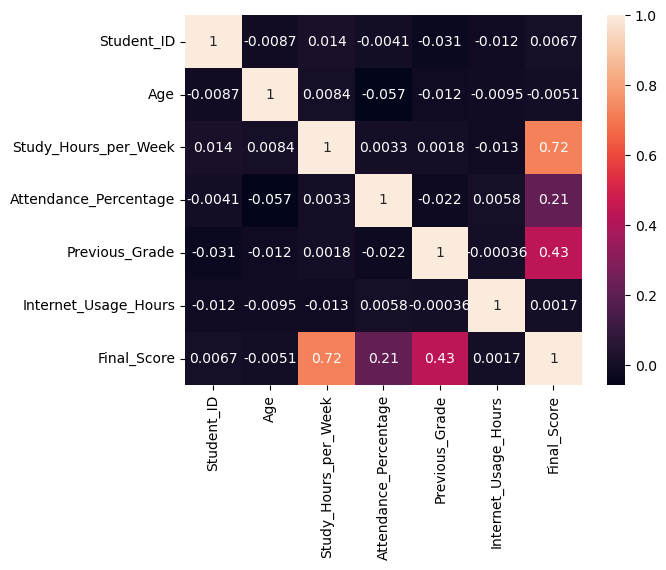

In [33]:
# Part-B :- DIAGNOSTIC ANALYTICS

# Correlation Analysis
correlation = data.corr(numeric_only=True)
print(correlation)

sns.heatmap(correlation, annot=True)
plt.show()

In [34]:
# Fail Student
fail_students = data[data['Result'] == 'Fail']
fail_students.describe()

,Student_ID,Age,Study_Hours_per_Week,Attendance_Percentage,Previous_Grade,Internet_Usage_Hours,Final_Score
count,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000
mean,495.660105,21.007874,19.288714,73.467192,64.028871,5.098425,38.668556
std,289.259408,2.052514,9.388567,14.445315,15.571351,2.537399,6.875980
min,1.000000,18.000000,5.000000,50.000000,40.000000,1.000000,19.900000
25%,245.500000,19.000000,12.000000,60.000000,50.000000,3.000000,33.835000
50%,491.500000,21.000000,18.000000,73.000000,62.000000,5.000000,39.175000
75%,742.750000,23.000000,26.000000,86.000000,77.000000,7.000000,44.255000
max,1000.000000,24.000000,39.000000,99.000000,94.000000,9.000000,49.990000


In [35]:
# Compare Pass and Fail 

data.groupby('Result')[['Study_Hours_per_Week','Attendance_Percentage','Final_Score']].mean()

,Study_Hours_per_Week,Attendance_Percentage,Final_Score
Result,,,
Fail,19.288714,73.467192,38.668556
Pass,30.941176,79.000000,54.882311


In [36]:
# PART C :– PREDICTIVE ANALYTICS

# Prepare Data
X = data[['Study_Hours_per_Week', 'Attendance_Percentage', 'Previous_Grade']]
y = data['Final_Score']


In [41]:
# Train-Test Split and Train Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# Evaluate Model
from sklearn.metrics import r2_score

predictions = model.predict(X_test)
print("R2 Score:", r2_score(y_test, predictions))

R2 Score: 0.7873674997771136


In [59]:
# Predict Student Score
new_student = pd.DataFrame([[13, 85, 75]],
                           columns=[
                               "Study_Hours_per_Week",
                               "Attendance_Percentage",
                               "Previous_Grade"
                           ])

predicted_score = model.predict(new_student)
print("Predicted Score:", predicted_score)

Predicted Score: [39.93100574]


In [60]:
# Part D :- PRESCRIPTIVE ANALYTICS

# Decision Logic 
if predicted_score > avg_score:
    print("Recommendation: Student likely to PASS")
else:
    print("Recommendation: Needs Improvement")

Recommendation: Needs Improvement
